In [90]:
# Pour la manipulation de tableaux et Dataframes
import numpy as np
import pandas as pd

# Pour la visualisation des performances
import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib import cm
import itertools

# Pour la construction de note modèle
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Rescaling

# Pour évaluer les modèles
from sklearn import metrics 

In [91]:
import os
import numpy as np
from keras.utils import load_img, img_to_array

def load_dataset_from_directory(base_dir, img_size, color_mode):
    X = []
    y = []
    class_names = []

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        class_index = len(class_names) - 1

        for root, dirs, files in os.walk(class_path):
            for filename in files:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    file_path = os.path.join(root, filename)

                    img = load_img(file_path, target_size=img_size, color_mode=color_mode)
                    img_array = img_to_array(img)

                    X.append(img_array)
                    y.append(class_index)

    return np.array(X), np.array(y), class_names

In [92]:
chemin_good=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Train"
chemin_test=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Test"
from tensorflow.keras.preprocessing.image import load_img, img_to_array

train_dir = chemin_good
test_dir  = chemin_test

img_size = (128, 128)   # 
color_mode = "rgb"  # ou "grayscale"


X_train, y_train, class_names_train = load_dataset_from_directory(train_dir, img_size, color_mode)
X_test, y_test, class_names_test = load_dataset_from_directory(test_dir, img_size, color_mode)


# Shape de X_train and y_train
print('Shape of X:', X_train.shape)
print('Shape of y:', y_train.shape)

# Changer la forme de X_train et X_test
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
# Shape de X_train and y_train
print('Shape of X:', X_train.shape)
print('Shape of y:', y_train.shape)



Shape of X: (5865, 128, 128, 3)
Shape of y: (5865,)
Shape of X: (5865, 49152)
Shape of y: (5865,)


In [93]:
y_train_encoded = to_categorical(y_train)
y_test_encoded = to_categorical(y_test) 

# La méthode *utils.to_categorical* transforme les chiffres en vecteurs
# remplis de zéros, sauf à la position du chiffre en question qui vaut 1 
# Par exemple, 3 devient (0,0,0,1,0,0,0,0,0,0)

# Ainsi y_train et y_test deviennent des matrices de mêmes nombres de lignes mais avec autant
# de colonnes que de classes (chiffres uniques) qu'elles possèdent.

In [94]:
num_pixels = X_train.shape[1]
num_classes = y_test_encoded.shape[1]
print("num_pixels : ",num_pixels)
print("num_classes : ",num_classes)


num_pixels :  49152
num_classes :  15


In [95]:
# Création du modèle séquentiel
model = Sequential()

# Ajout de la couche de rescaling comme première couche
model.add(Rescaling(1./255))
                                    
# Ajout des couches
model.add(Dense(units=20, 
                activation="relu", 
                kernel_initializer='normal', 
                input_shape=(num_pixels,)))

model.add(Dense(units=num_classes, 
                activation="softmax", 
                kernel_initializer='normal'))


C:\Users\fabbg\anaconda3\envs\tf_gpu\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [96]:
model.compile(loss='categorical_crossentropy',  # fonction de perte
              optimizer='adam',                 # algorithme d'optimisation
              metrics=['accuracy'])             # métrique d'évaluation


In [97]:
from sklearn.utils import shuffle

X_train, y_train_encoded = shuffle(
    X_train,
    y_train_encoded,
    random_state=42
)
training_history = model.fit(X_train, y_train_encoded,  # données d'entraînement
                             epochs=20,                 # nombre d'epochs
                             batch_size=64,            # taille des batchs
                             validation_split=0.2
                            )


Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6038 - loss: 1.1384 - val_accuracy: 0.8559 - val_loss: 0.4454
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8259 - loss: 0.3855 - val_accuracy: 0.8917 - val_loss: 0.2869
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8576 - loss: 0.3020 - val_accuracy: 0.9122 - val_loss: 0.2621
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9054 - loss: 0.2460 - val_accuracy: 0.9318 - val_loss: 0.2105
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9130 - loss: 0.2160 - val_accuracy: 0.9182 - val_loss: 0.1861
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9246 - loss: 0.1972 - val_accuracy: 0.8048 - val_loss: 0.4259
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9339 - loss: 0.1827 - val_accuracy: 0.9591 - val_loss: 0.1447
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9280 - loss: 0.1849 - val_accuracy: 0.9301 - v

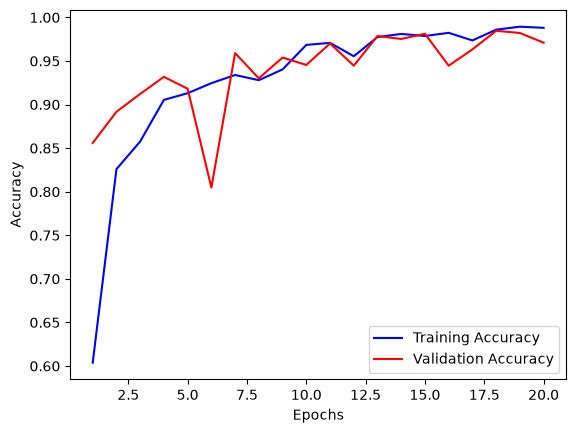

In [98]:
train_acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']

# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 21, 1),
         training_history.history['accuracy'],
         label = 'Training Accuracy',
         color = 'blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 , 21, 1),
         training_history.history['val_accuracy'], 
         label = 'Validation Accuracy',
         color = 'red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()


In [99]:
test_pred = model.predict(X_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [100]:
model.evaluate(X_test, y_test_encoded)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9849 - loss: 0.0681


[0.06807185709476471, 0.9849275350570679]

In [101]:
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

0.0 255.0
4.0 255.0


In [102]:
print(X_train.shape)
print(y_train_encoded.shape)
print(np.unique(y_train))
print(num_classes)
print(training_history.history['val_accuracy'])

(5865, 49152)
(5865, 15)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
15
[0.8559249639511108, 0.8917306065559387, 0.9121909737586975, 0.9317988157272339, 0.9181585907936096, 0.8047741055488586, 0.9590792655944824, 0.9300937652587891, 0.9539641737937927, 0.9454390406608582, 0.9701619744300842, 0.9445865154266357, 0.9786871075630188, 0.9752770662307739, 0.981244683265686, 0.9445865154266357, 0.9633418321609497, 0.9846547245979309, 0.9820972084999084, 0.9710144996643066]


In [103]:
test_pred = model.predict(X_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [104]:
test_pred_class = test_pred.argmax(axis=1)
y_test_class = y_test_encoded.argmax(axis=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       132
           3       0.94      0.99      0.96       117
           4       0.85      0.90      0.88        78
           5       0.99      1.00      1.00       110
           6       0.97      1.00      0.98       124
           7       1.00      1.00      1.00       115
           8       1.00      1.00      1.00       167
           9       0.99      1.00      1.00       160
          10       1.00      0.89      0.94       117
          11       1.00      1.00      1.00        42
          12       1.00      0.96      0.98       100
          13       1.00      1.00      1.00        79
          14       1.00      1.00      1.00       151

    accuracy                           0.98      1725
   macro avg       0.98      0.98      0.98      1725
weighted avg       0.99   

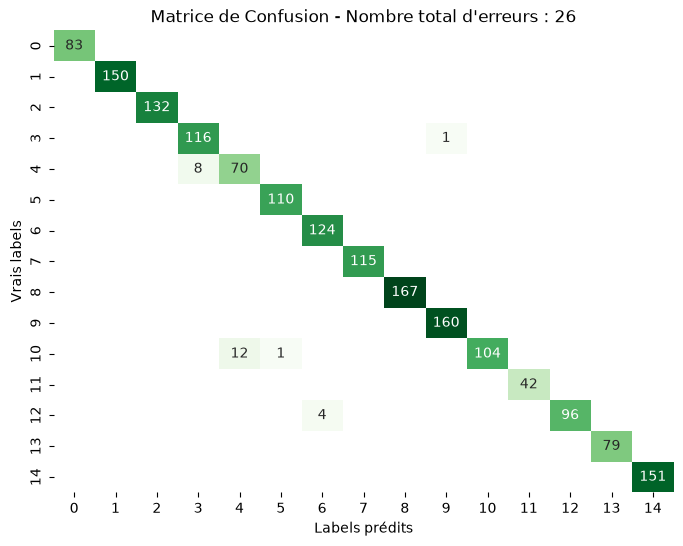

In [105]:
print(metrics.classification_report(y_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)
mask=(cnf_matrix == 0)
#nb total erreurs
nb_erreurs = cnf_matrix.sum() - np.trace(cnf_matrix)
# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de Confusion - Nombre total d'erreurs : "+str(nb_erreurs))
sns.heatmap(cnf_matrix, cmap='Greens', mask=mask, annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()


In [106]:
for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    if cnf_matrix[i, j] > 0.000 and i != j:  # Seuil de 0.0% pour les erreurs significatives
        print(f"{cnf_matrix[i, j]:.0f} des instances de la catégorie {i} ont été classées comme {j}.")


1 des instances de la catégorie 3 ont été classées comme 9.
8 des instances de la catégorie 4 ont été classées comme 3.
12 des instances de la catégorie 10 ont été classées comme 4.
1 des instances de la catégorie 10 ont été classées comme 5.
4 des instances de la catégorie 12 ont été classées comme 6.


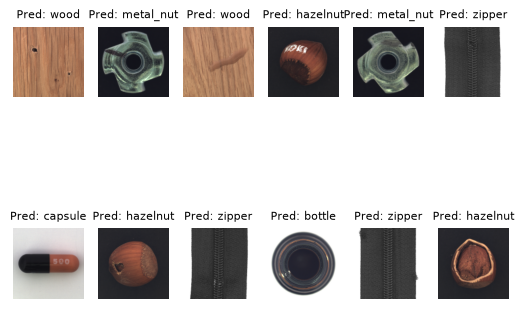

In [107]:
j = 1

for i in np.random.choice(np.arange(0, len(y_test)), size=12):
    img = X_test[i] 
    
    # Redimensionnement de l'image
    img = img.reshape(128, 128,3).astype(np.uint8)
    
    # Sélection de la sous-figure
    plt.subplot(2, 6, j)
    j = j + 1
    
    # Suppression des axes
    plt.axis('off')
    
    # Affichage de l'image en niveaux de gris
    plt.imshow(img, cmap = cm.binary)
    plt.title('Pred: ' + str(class_names_train[test_pred_class[i]]),fontsize=8)

In [108]:
print("Classes :", class_names_train)

Classes : ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


26
[373, 484, 497, 503, 528, 529, 544, 547, 548, 1239, 1249, 1270, 1305, 1311, 1314, 1319, 1329, 1342, 1345, 1350, 1351, 1352, 1487, 1488, 1492, 1493]
1725


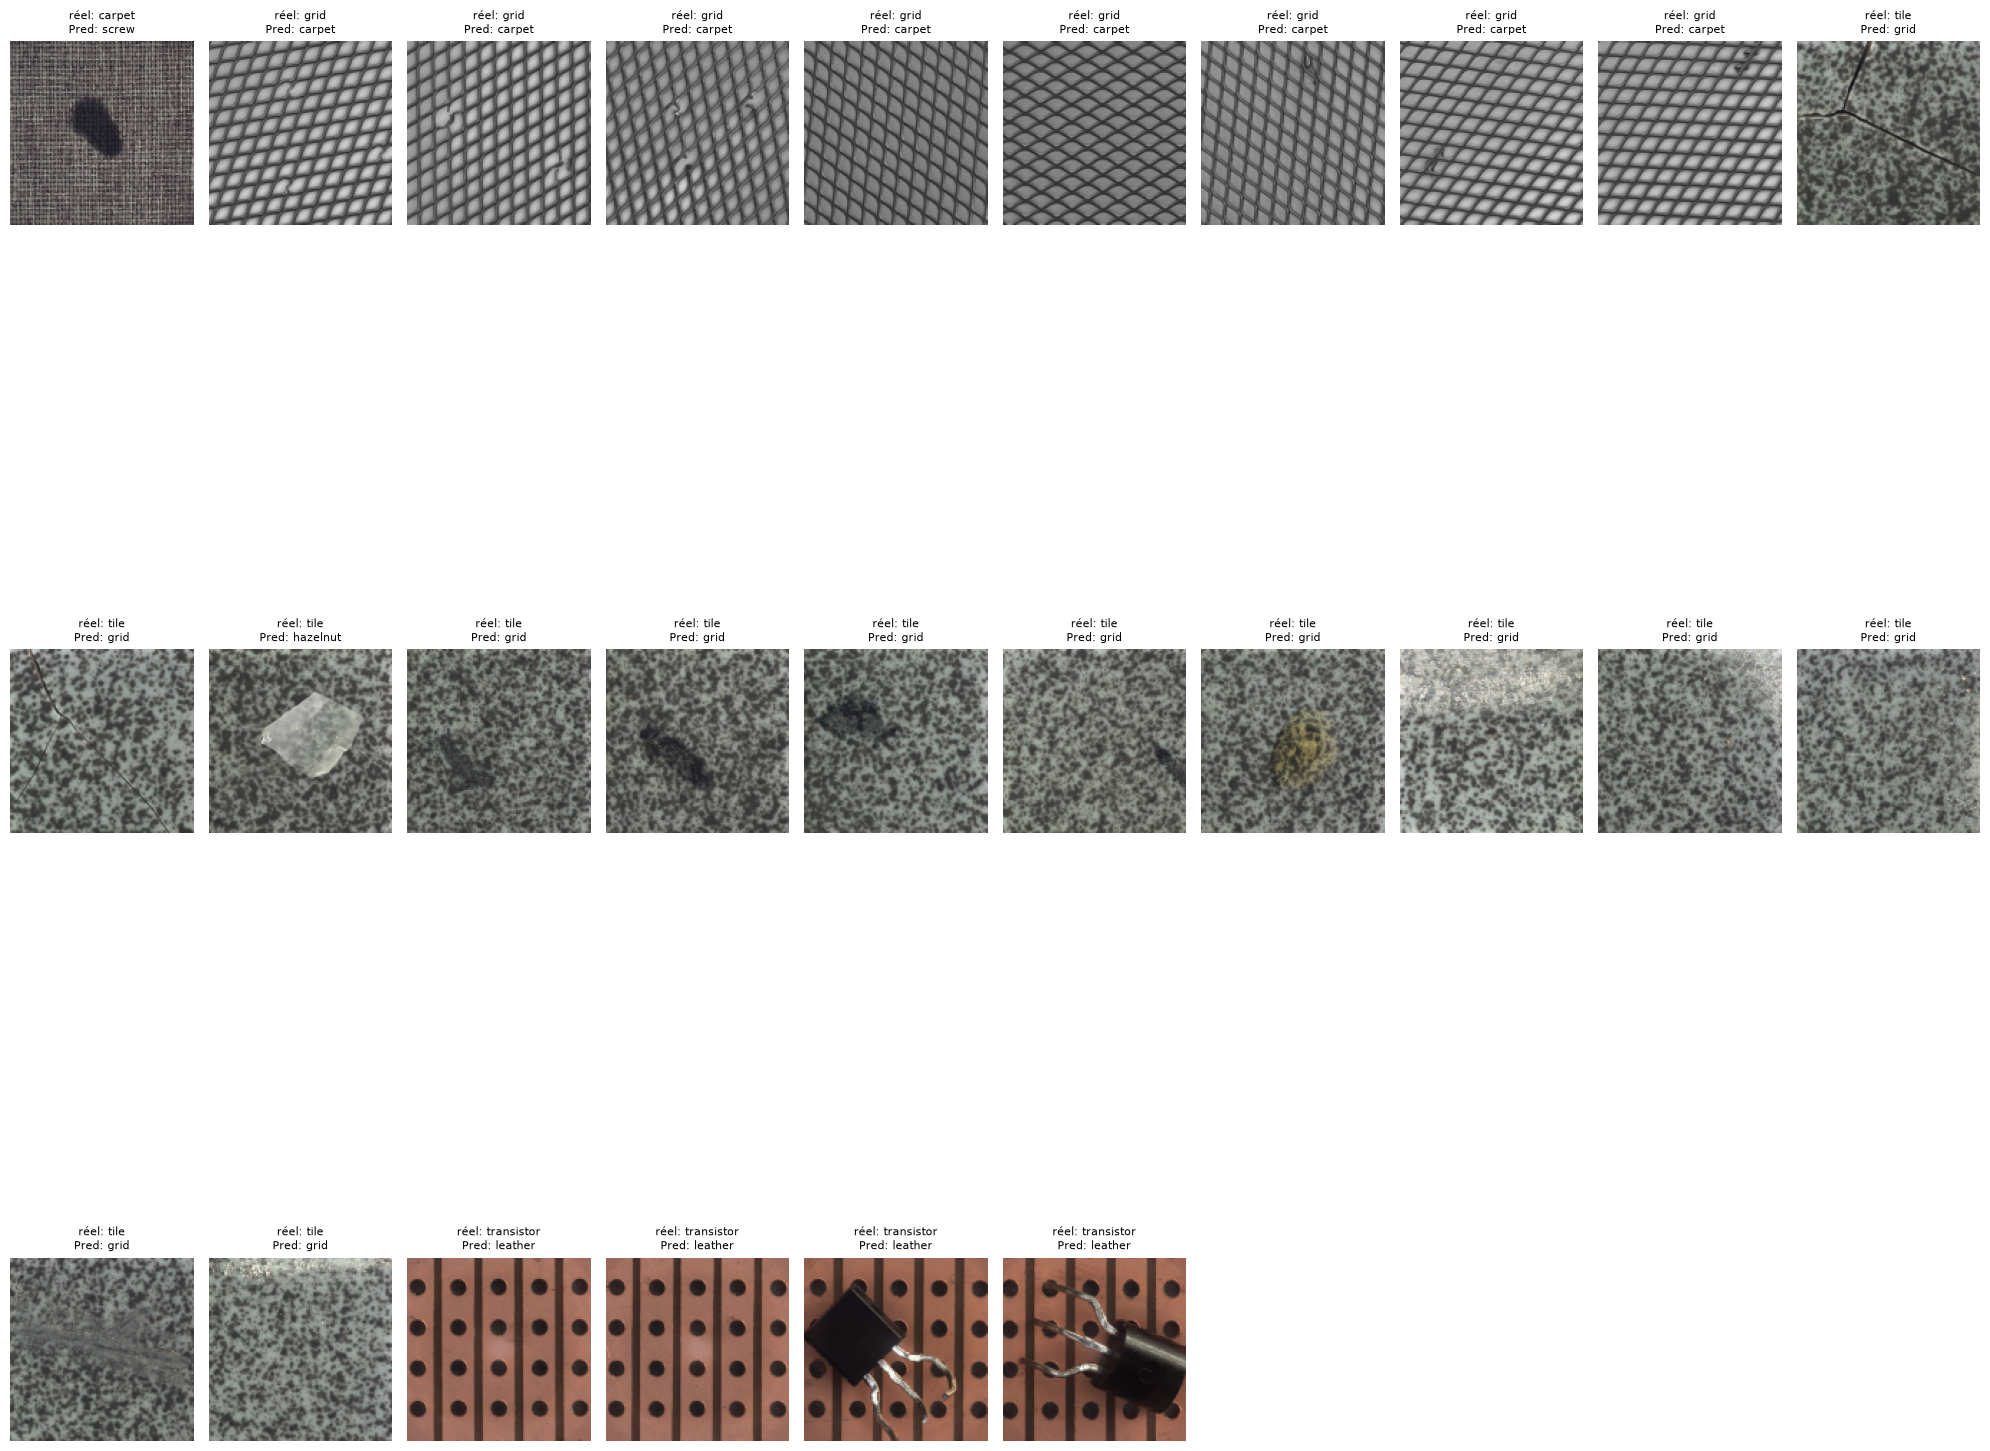

In [109]:
############ Défauts
enr_defauts=[]
for i in range(1,len(y_test)):
        if y_test_class[i] != test_pred_class[i]:
            enr_defauts.append(i)
            
print(len(enr_defauts))
print(enr_defauts)

nb_img_par_couche=10
    
j = 1
plt.figure(figsize=(20, 20))
y_prec=0
num_sortis=[]
print(len(y_test))
for i in enr_defauts:
    img = X_test[i].reshape(128, 128, 3).astype(np.uint8)

    plt.subplot((nb_erreurs // nb_img_par_couche) + 1, nb_img_par_couche, j)
    plt.axis('off')
    plt.imshow(img)

    plt.title(
        f"réel: {class_names_train[y_test_class[i]]}\nPred: {class_names_train[test_pred_class[i]]}",
        fontsize=8
    )
    
    j += 1

               
plt.tight_layout()
plt.show()